In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix
import numpy as np
import random
import json
import seaborn as sns
from tqdm import tqdm

In [2]:
DIR_DATA="./data/Dataset/"
DIR_NET_SAVING="./data/net/"
DIR_RESULTS="./data/"

In [3]:
manualSeed=1
torch.manual_seed(manualSeed)
random.seed(manualSeed)
np.random.seed(manualSeed)
g = torch.Generator()
g.manual_seed(manualSeed)

In [4]:
def remove_outliers(data_dict):
    features = np.array(data_dict["features"])
    labels = np.array(data_dict["label"])

    # Calculate thresholds for each of the 15 features independently
    borne_min = np.quantile(features, 0.01, axis=0)
    borne_max = np.quantile(features, 0.99, axis=0)

    # Create a boolean mask where True means the row is within the 1% - 99% range for ALL features
    is_good_row = np.all((features >= borne_min) & (features <= borne_max), axis=1)

    # Filter and update the dictionary with clean data
    data_dict["features"] = features[is_good_row].tolist()
    data_dict["label"] = labels[is_good_row].tolist()

    return data_dict



def clean_subject_dataset(data_dict):
    features = np.array(data_dict["features"])
    labels = np.array(data_dict["label"])

    clean_features_list = []
    clean_labels_list = []

    # Process each of the 4 emotional states (labels 1 to 4) separately
    for state_label in range(1, 5):
        # Mask to isolate the current state
        state_mask = labels == state_label

        # Skip if this specific state has no data points
        if not np.any(state_mask):
            continue

        state_dict = {
            "features": features[state_mask].tolist(),
            "label": labels[state_mask].tolist(),
        }

        # Apply our updated outlier removal function to this state
        cleaned_state_dict = remove_outliers(state_dict)

        # Collect the cleaned data
        clean_features_list.extend(cleaned_state_dict["features"])
        clean_labels_list.extend(cleaned_state_dict["label"])

    # Return the fully reconstructed clean dataset
    return {"features": clean_features_list, "label": clean_labels_list}


def merge_subject_datasets(dataset_list):
    combined_features = []
    combined_labels = []

    for data_dict in dataset_list:
        combined_features.append(np.array(data_dict["features"]))
        combined_labels.append(np.array(data_dict["label"]))

    # Use np.vstack and np.concatenate for high-speed memory block stitching
    return {
        "features": np.vstack(combined_features).tolist(),
        "label": np.concatenate(combined_labels).tolist(),
    }

import numpy as np


def downsample_to_target(data_dict, indices, target_size):
    total_indices = len(indices)

    # Calculate an even stepping factor for uniform slicing
    step = int(np.ceil(total_indices / target_size))

    # Slice the indices uniformly
    selected_indices = np.random.choice( indices, target_size, replace=False)

    features = [data_dict["features"][idx] for idx in selected_indices]
    labels = [data_dict["label"][idx] for idx in selected_indices]

    return features, labels


def balance_subject_dataset(data_dict):
    labels = np.array(data_dict["label"])

    # Find indices for each class
    idx_neutral = np.where(labels == 1)[0]
    idx_stress = np.where(labels == 2)[0]
    idx_amusement = np.where(labels == 3)[0]
    idx_meditation = np.where(labels == 4)[0]

    # Stress (Label 2) is our anchor target size
    stress_count = len(idx_stress)

    # Split that target size equally among the 3 non-stress classes
    target_per_non_stress = stress_count // 3

    balanced_features = []
    balanced_labels = []

    # Downsample and collect each class
    # 1. Neutral
    f_neut, l_neut = downsample_to_target(
        data_dict, idx_neutral, target_per_non_stress
    )
    balanced_features.extend(f_neut)
    balanced_labels.extend(l_neut)

    # 2. Stress (Keep 100% of it, no downsampling needed)
    f_str = [data_dict["features"][idx] for idx in idx_stress]
    l_str = [data_dict["label"][idx] for idx in idx_stress]
    balanced_features.extend(f_str)
    balanced_labels.extend(l_str)

    # 3. Amusement
    f_amu, l_amu = downsample_to_target(
        data_dict, idx_amusement, target_per_non_stress
    )
    balanced_features.extend(f_amu)
    balanced_labels.extend(l_amu)

    # 4. Meditation
    f_med, l_med = downsample_to_target(
        data_dict, idx_meditation, target_per_non_stress
    )
    balanced_features.extend(f_med)
    balanced_labels.extend(l_med)

    return {"features": balanced_features, "label": balanced_labels}

In [5]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset


class WESADDataset(Dataset):
    def __init__(self, data_dict, scaler=None):
        self.samples = []

        raw_features = np.array(data_dict["features"])  # Shape: (N, 15)
        raw_labels = np.array(data_dict["label"])  # Shape: (N,)

        # --- Fit or Apply Standardization ---
        if scaler is None:
            self.scaler = StandardScaler()
            standardized_features = self.scaler.fit_transform(raw_features)
        else:
            self.scaler = scaler
            standardized_features = self.scaler.transform(raw_features)

        # --- Build Tensor Samples ---
        for i in range(len(raw_labels)):
            features_tensor = torch.tensor(standardized_features[i], dtype=torch.float32)
            
            # Binary target: 1 for Stress (Label 2), 0 for No Stress (Labels 1, 3, 4)
            is_stressed = 1 if raw_labels[i] == 2 else 0
            is_stressed_tensor = torch.tensor(is_stressed, dtype=torch.float32)
            
            raw_label_tensor = torch.tensor(raw_labels[i], dtype=torch.long)

            self.samples.append((features_tensor, is_stressed_tensor, raw_label_tensor))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]

In [6]:
# 1. Subject list (S17 is excluded as it is entirely isolated in the Testing folder)
name_list = [
    "WESADECG_S2.json",
    "WESADECG_S3.json",
    "WESADECG_S4.json",
    "WESADECG_S5.json",
    "WESADECG_S6.json",
    "WESADECG_S7.json",
    "WESADECG_S8.json",
    "WESADECG_S9.json",
    "WESADECG_S10.json",
    "WESADECG_S11.json",
    "WESADECG_S13.json",
    "WESADECG_S14.json",
    "WESADECG_S15.json",
    "WESADECG_S16.json",
]

# --- Step 1: Pre-load and clean all subject data ONCE ---
print("Pre-loading and cleaning subject data...")
preloaded_subjects = []

for file_name in name_list:
    file_path = os.path.join(DIR_DATA, file_name)
    with open(file_path, "r") as f:
        raw_data = json.load(f)

    # 1. Balance the subject dataset (Equivalent to original eq_dic)
    balanced_data = balance_subject_dataset(raw_data)

    # 2. Extract and remove outliers per state (Equivalent to extract_ds_from_dict)
    clean_data = clean_subject_dataset(balanced_data)

    preloaded_subjects.append(clean_data)

print(f"Successfully cached {len(preloaded_subjects)} subjects in memory.\n")


# --- Step 2: Generate Cross-Validation splits using combinations ---
print("Generating cross-validation splits...")
cv_splits = []
combination_counter = 0
num_subjects = len(name_list)

for k in range(num_subjects):
    for j in range(k + 1, num_subjects):

        # Pick 2 subjects for validation
        val_subject_1 = preloaded_subjects[k]
        val_subject_2 = preloaded_subjects[j]

        # Combine validation subjects
        dict_val_combined = merge_subject_datasets([val_subject_1, val_subject_2])

        # Gather remaining 12 subjects for training
        train_subjects_pool = []
        for i in range(num_subjects):
            if i != k and i != j:
                train_subjects_pool.append(preloaded_subjects[i])

        assert len(train_subjects_pool) == 12

        # Combine training subjects
        dict_train_combined = merge_subject_datasets(train_subjects_pool)

        # Store the prepared dictionaries along with subject indices for tracking
        cv_splits.append(
            {
                "train_dict": dict_train_combined,
                "val_dict": dict_val_combined,
                "val_idx_1": k,
                "val_idx_2": j,
            }
        )

        combination_counter += 1
        if combination_counter % 10 == 0:
            print(f"Generated {combination_counter}/91 splits...")

print(f"\nFinal: Generated {len(cv_splits)} distinct validation folds.")

Pre-loading and cleaning subject data...
Successfully cached 14 subjects in memory.

Generating cross-validation splits...
Generated 10/91 splits...
Generated 20/91 splits...
Generated 30/91 splits...
Generated 40/91 splits...
Generated 50/91 splits...
Generated 60/91 splits...
Generated 70/91 splits...
Generated 80/91 splits...
Generated 90/91 splits...

Final: Generated 91 distinct validation folds.


In [7]:
# --- Generate PyTorch Dataset objects for each cross-validation split ---
print("Converting dictionaries to PyTorch Dataset objects with scaling...")
cv_datasets = []
dataset_counter = 0

for split in cv_splits:
    # 1. Instantiate the Training Dataset (This will fit the StandardScaler)
    train_dataset = WESADDataset(split["train_dict"], scaler=None)

    # 2. Instantiate the Validation Dataset using the Training Dataset's scaler
    val_dataset = WESADDataset(split["val_dict"], scaler=train_dataset.scaler)

    # 3. Append the objects and the subject trackers to our dataset list
    cv_datasets.append(
        {
            "train_set": train_dataset,
            "val_set": val_dataset,
            "val_idx_1": split["val_idx_1"],
            "val_idx_2": split["val_idx_2"],
        }
    )

    dataset_counter += 1
    if dataset_counter % 10 == 0:
        print(f"Converted {dataset_counter}/91 splits into PyTorch datasets...")

print(
    f"\nFinal: Successfully prepared {len(cv_datasets)} operational training/validation dataset pairs."
)

Converting dictionaries to PyTorch Dataset objects with scaling...
Converted 10/91 splits into PyTorch datasets...
Converted 20/91 splits into PyTorch datasets...
Converted 30/91 splits into PyTorch datasets...
Converted 40/91 splits into PyTorch datasets...
Converted 50/91 splits into PyTorch datasets...
Converted 60/91 splits into PyTorch datasets...
Converted 70/91 splits into PyTorch datasets...
Converted 80/91 splits into PyTorch datasets...
Converted 90/91 splits into PyTorch datasets...

Final: Successfully prepared 91 operational training/validation dataset pairs.


In [9]:
def initialize_weights(module):

    if isinstance(module, nn.Linear):

        nn.init.kaiming_normal_(
            module.weight,
            a=0.1,
            nonlinearity='leaky_relu'
        )

        if module.bias is not None:
            module.bias.data.zero_()

    elif isinstance(module, nn.BatchNorm1d):

        module.weight.data.fill_(1.0)

        module.bias.data.zero_()

class ECGStressClassifier(nn.Module):
# """Feedforward Neural Network for ECG stress classification"""

    def __init__(self):
        super(ECGStressClassifier, self).__init__()
        
        self.network = nn.Sequential(
        
            nn.Linear(15, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
        
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
        
            nn.Linear(16, 1)
        )

        # Apply the weight initialization strategy recursively across all layers
        self.network.apply(initialize_weights)

    def forward(self, x):
        return self.network(x)

In [11]:
def train_model(net, train_loader, val_loader, optimizer, num_epochs, save_path, patience=5):    
    criterion = nn.BCEWithLogitsLoss()
    best_val_loss = float('inf')
    early_stop_counter = 0
    
    history = {"train_loss": [], "val_loss": []}
    
    for epoch in range(num_epochs):
        # --- Training Phase ---
        net.train()
        train_losses = []
        for inputs, targets, _ in train_loader:
            inputs, targets = inputs.to(device), targets.view(-1, 1).to(device)
            
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            
        # --- Validation Phase ---
        net.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, targets, _ in val_loader:
                inputs, targets = inputs.to(device), targets.view(-1, 1).to(device)
                outputs = net(inputs)
                loss = criterion(outputs, targets)
                val_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        
        # --- Early Stopping Logic & Best Model Saving ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            # Save the best model only
            torch.save(net.state_dict(), save_path)
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
                
    return history

In [13]:
# ============================================================
# Device & Reproducibility Configuration
# ============================================================

ngpu = 1

device = torch.device(
    "cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu"
)

print(f"Device set to: {device}")

# Strong reproducibility settings
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# Hyperparameters
# ============================================================

batch_size = 32
num_epochs = 20
learning_rate = 1e-4

folder_name = "trained_models"

# Create folder if it doesn't exist
os.makedirs(folder_name, exist_ok=True)

results = []

# ============================================================
# 91-Fold Cross Validation
# ============================================================

for n, split in enumerate(
    tqdm(cv_datasets, desc="Running Cross-Validation")
):

    # --------------------------------------------------------
    # Fold-specific Generator
    # Different shuffle order for every fold
    # while keeping full reproducibility
    # --------------------------------------------------------

    fold_generator = torch.Generator()

    fold_generator.manual_seed(42 + n)

    # --------------------------------------------------------
    # Initialize Model
    # --------------------------------------------------------

    net = ECGStressClassifier().to(device)

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = optim.Adam(
        net.parameters(),
        lr=learning_rate
    )

    # --------------------------------------------------------
    # Training DataLoader
    # --------------------------------------------------------
    # drop_last=True:
    # Prevent BatchNorm instability from tiny final batches
    # --------------------------------------------------------

    train_loader = torch.utils.data.DataLoader(
        split["train_set"],
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=fold_generator,
        drop_last=True
    )

    # --------------------------------------------------------
    # Validation DataLoader
    # --------------------------------------------------------
    # IMPORTANT:
    # Never drop validation samples
    # --------------------------------------------------------

    val_loader = torch.utils.data.DataLoader(
        split["val_set"],
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        drop_last=False
    )

    # --------------------------------------------------------
    # Train Model
    # --------------------------------------------------------

    history = train_model(
        net=net,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        num_epochs=num_epochs,
        save_path=os.path.join(
            folder_name,
            f"net_{split['val_idx_1']}_{split['val_idx_2']}.pth"
        ),
        patience=5
    )

    # --------------------------------------------------------
    # Save Fold Results
    # --------------------------------------------------------

    results.append({
        "history": history,
        "idx1": split["val_idx_1"],
        "idx2": split["val_idx_2"]
    })

print("\nCross-validation training completed successfully.")

Device set to: cpu


Running Cross-Validation:   1%|▏                 | 1/91 [00:01<02:52,  1.92s/it]

Early stopping at epoch 5


Running Cross-Validation:   2%|▍                 | 2/91 [00:03<02:50,  1.91s/it]

Early stopping at epoch 5


...

Early stopping at epoch 19


Running Cross-Validation:  98%|████████████████▋| 89/91 [08:12<00:12,  6.08s/it]

Early stopping at epoch 18


Running Cross-Validation: 100%|█████████████████| 91/91 [08:25<00:00,  5.55s/it]


Cross-validation training completed successfully.


In [14]:
# Save Results
# --- 1. Custom JSON Encoder for NumPy types ---
class NpEncoder(json.JSONEncoder):
    """
    Custom encoder to handle NumPy types (int, float, array)
    which are not natively serializable by the standard json library.
    """
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)
        
# --- 2. Saving the training results ---
# Ensure you use 'results' (the variable used in your CV loop) instead of 'L'
results_to_save = {
    "hyperparameters": {
        "batch_size": batch_size,
        "num_epochs": num_epochs,
        "learning_rate": learning_rate,
        "patience": 3
    },
    "training_history": results  # Changed from L to results
}

# Ensure the directory exists before writing
import os
os.makedirs(DIR_RESULTS, exist_ok=True)

# Write to JSON file
try:
    with open(os.path.join(DIR_RESULTS, "results.json"), "w") as file:
        json.dump(results_to_save, file, cls=NpEncoder, indent=4)
    print(f"Successfully saved results to {DIR_RESULTS}results.json")
except Exception as e:
    print(f"An error occurred while saving: {e}")

Successfully saved results to ./data/results.json


In [15]:
# Load Results
# --- 1. Load the Results ---
# Define the path to the results file
results_file_path = os.path.join(DIR_RESULTS, "results.json")

if os.path.exists(results_file_path):
    with open(results_file_path, "r") as file:
        data = json.load(file)
    
    # Extract the training history and metadata
    L = data.get("training_history", [])
    params = data.get("hyperparameters", {})
    
    print(f"Successfully loaded results. Found data for {len(L)} training splits.")
    print(f"Loaded hyperparameters: {params}")
else:
    print(f"Warning: Results file not found at {results_file_path}")
    L = []

# --- 2. Reproducibility & Device Configuration ---
def seed_worker(worker_id):
    """Ensures deterministic behavior in DataLoader workers."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Configuration settings
num_workers = 0  # Set to 0 for stability in Windows/Colab environments
batch_size = 32
ngpu = 1

# Automatically select device: GPU if available, otherwise CPU
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

print(f"Using device: {device}")

Successfully loaded results. Found data for 91 training splits.
Loaded hyperparameters: {'batch_size': 32, 'num_epochs': 20, 'learning_rate': 0.0001, 'patience': 3}
Using device: cpu


Evaluating models on validation sets...


Evaluation Progress: 100%|██████████████████████| 91/91 [00:01<00:00, 56.68it/s]


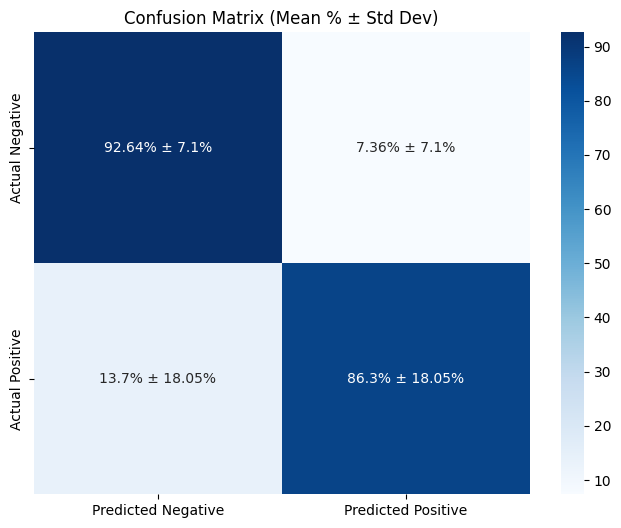

In [16]:
# --- 1. Define Helper Function for Confusion Matrix ---
def calculate_fold_confusion(net, loader, device):

    """
    Standard confusion matrix format:
    
    [[TN, FP],
     [FN, TP]]
    """

    cm = {
        'tp': 0,
        'fp': 0,
        'fn': 0,
        'tn': 0
    }

    net.eval()

    with torch.no_grad():

        for inputs, targets, _ in loader:

            inputs = inputs.to(device)

            targets = targets.to(device).view(-1)

            # Model outputs logits
            logits = net(inputs).view(-1)

            # Logit threshold 0 == probability threshold 0.5
            preds = (logits > 0).float()

            cm['tp'] += ((preds == 1) & (targets == 1)).sum().item()

            cm['fp'] += ((preds == 1) & (targets == 0)).sum().item()

            cm['fn'] += ((preds == 0) & (targets == 1)).sum().item()

            cm['tn'] += ((preds == 0) & (targets == 0)).sum().item()

    return np.array([
        [cm['tn'], cm['fp']],
        [cm['fn'], cm['tp']]
    ])
    
# --- 2. Metric Containers ---
acc_list, prec_list, recall_list, f1_list = [], [], [], []
confusion_list = []

# --- 3. Evaluation Loop over all 91 folds ---
print("Evaluating models on validation sets...")
for n, split in enumerate(tqdm(cv_datasets, desc="Evaluation Progress")):
    
    # Instantiate the model structure
    net = ECGStressClassifier().to(device)
    
    # Load the best weights saved during training
    # Note: These files are expected to be the final state saved during the training loop
    save_path = os.path.join("trained_models", f"net_{split['val_idx_1']}_{split['val_idx_2']}.pth")
    net.load_state_dict(torch.load(save_path, map_location=device))
    
    # Prepare DataLoader with drop_last=False to ensure full evaluation coverage
    val_loader = torch.utils.data.DataLoader(
        split["val_set"], 
        batch_size=batch_size, 
        shuffle=False, 
        drop_last=False
    )
    
    # Calculate confusion matrix for the current fold
    # The helper function handles the 3-element tuple returned by WESADDataset
    conf_matrix = calculate_fold_confusion(net, val_loader, device)
    
    # Calculate metrics
    total_samples = conf_matrix.sum()
    tn, fp = conf_matrix[0]
    fn, tp = conf_matrix[1]
    
    # Accuracy, Precision, Recall, F1
    acc = (tp + tn) / max(1, total_samples)
    precision = tp / max(1, (tp + fp))
    recall = tp / max(1, (tp + fn))
    f1 = 2 * (precision * recall) / max(1e-6, (precision + recall))
    
    # Store results
    acc_list.append(acc)
    prec_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    row_normalized = conf_matrix / np.maximum(
        conf_matrix.sum(axis=1, keepdims=True),
        1
    )
    
    confusion_list.append(100 * row_normalized)

# --- 4. Visualization: Confusion Matrix Heatmap ---
conf_mean = np.round(np.mean(confusion_list, axis=0), 2)
conf_std = np.round(np.std(confusion_list, axis=0), 2)

# Create annotated heatmap strings (mean +/- std)
annot_conf = [[f"{m}% ± {s}%" for m, s in zip(row_m, row_s)] for row_m, row_s in zip(conf_mean, conf_std)]

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mean, annot=annot_conf, fmt='', 
            xticklabels=[
                'Predicted Negative',
                'Predicted Positive'
            ],
            
            yticklabels=[
                'Actual Negative',
                'Actual Positive'
            ],
            cmap='Blues')
plt.title("Confusion Matrix (Mean % ± Std Dev)")
plt.show()

In [25]:
def plot_metric_distribution(metric_values, metric_name, color):

    plt.figure(figsize=(8, 5))

    plt.hist(
        metric_values,
        bins=20,
        color=color,
        edgecolor='black'
    )

    plt.title(f'{metric_name} distribution across folds')

    plt.xlabel(metric_name)

    plt.ylabel('Number of folds')

    mean_val = np.mean(metric_values)

    std_val = np.std(metric_values)

    xmin, xmax = plt.xlim()

    xpos = xmin + (xmax - xmin) * 0.05

    plt.text(
        xpos,
        max(plt.ylim()) * 0.90,
        f"Mean: {mean_val:.3f}"
    )

    plt.text(
        xpos,
        max(plt.ylim()) * 0.84,
        f"Std: {std_val:.3f}"
    )

    plt.axvline(
        mean_val,
        color='red',
        linestyle='dashed',
        linewidth=2
    )

    plt.show()

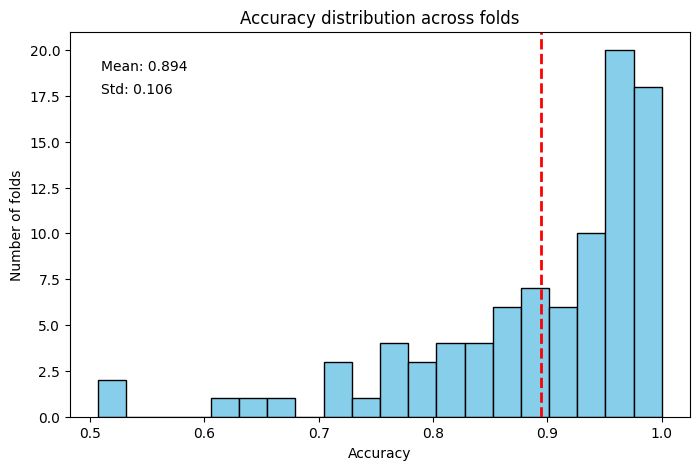

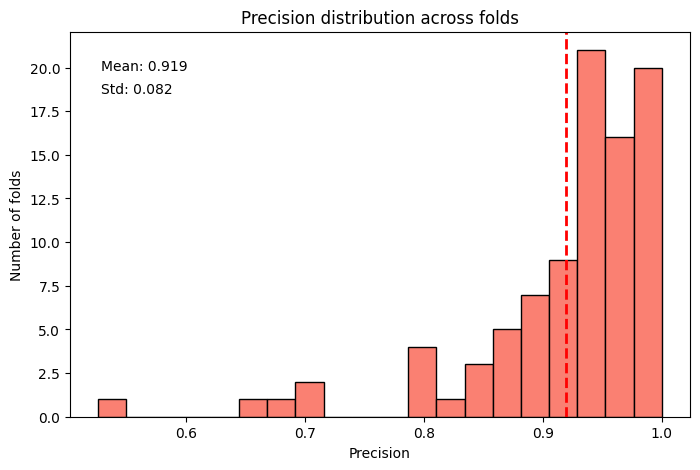

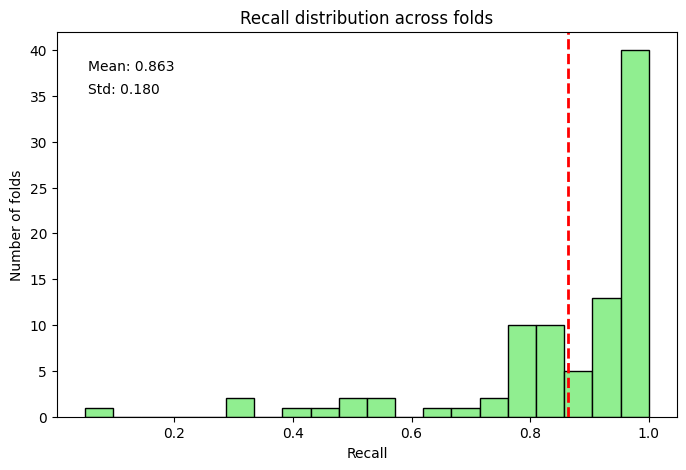

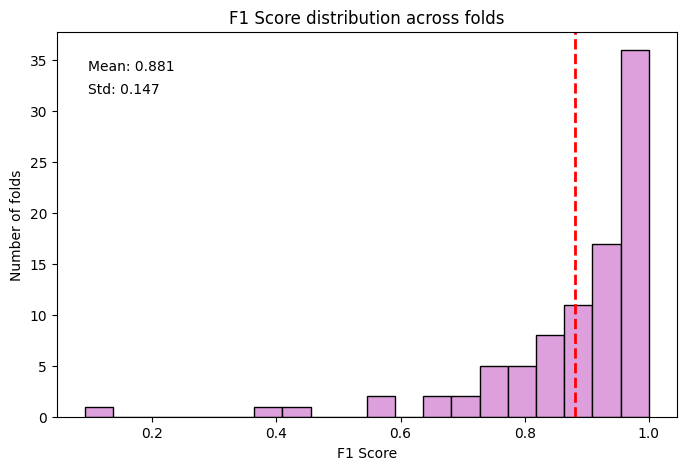

In [26]:
plot_metric_distribution(acc_list, "Accuracy", "skyblue")

plot_metric_distribution(prec_list, "Precision", "salmon")

plot_metric_distribution(recall_list, "Recall", "lightgreen")

plot_metric_distribution(f1_list, "F1 Score", "plum")